# 📋 Alimony Amount Prediction

Predicts monthly alimony amount based on financial, demographic and social features of divorced couples.

---

### Table of Contents
1. [Imports & Data Loading](#imports)
2. [Data Cleaning](#cleaning)
3. [Exploratory Data Analysis](#eda)
4. [Training](#training)
5. [Evaluation & Visualization](#evaluation)
6. [Model Comparison](#comparison)
7. [Prediction on New Data](#newdata)

---
## 1. Imports & Data Loading

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df=pd.read_csv("../data/alimony_dataset.csv")
df.head()

,case_id,husband_age,wife_age,marriage_duration_years,num_children,husband_monthly_income,wife_monthly_income,husband_assets,wife_assets,monthly_household_expenses,...,wife_employment,standard_of_living,wife_health_condition,husband_health_condition,wife_career_sacrifice,custody_with,marriage_type,divorce_type,monthly_alimony_amount,alimony_duration_months
0,1,53,56,23,1,26230,11288,114376,16640,12150,...,Employed,Low,Good,Good,No,Shared,Arranged,Contested,15651,218
1,2,39,38,6,2,163050,113632,3008377,818515,47568,...,Employed,Upper-Middle,Good,Moderate,No,Shared,Love,Contested,7964,87
2,3,32,35,10,4,29048,0,230370,25102,9447,...,Homemaker,Low,Good,Good,Yes,Husband,Arranged,Contested,33069,164
3,4,45,42,16,3,57961,0,2354372,531133,19090,...,Homemaker,Middle,Moderate,Good,Yes,Wife,Arranged,Contested,42448,247
4,5,43,48,11,4,118398,110308,9247670,106644,41819,...,Self-Employed,Upper-Middle,Good,Good,No,Shared,Arranged,Contested,9761,124


---
## 2. Data Cleaning

Drop irrelevant columns, check for missing values and handle them without modifying any data, then apply label encoding.

In [19]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# custody_with has missing values — fill with mode (most frequent value)
df['custody_with'] = df['custody_with'].fillna(df['custody_with'].mode()[0])
print('\nMissing after fix:', df.isnull().sum().sum())

Missing values per column:
case_id                         0
husband_age                     0
wife_age                        0
marriage_duration_years         0
num_children                    0
husband_monthly_income          0
wife_monthly_income             0
husband_assets                  0
wife_assets                     0
monthly_household_expenses      0
husband_education               0
wife_education                  0
husband_employment              0
wife_employment                 0
standard_of_living              0
wife_health_condition           0
husband_health_condition        0
wife_career_sacrifice           0
custody_with                  869
marriage_type                   0
divorce_type                    0
monthly_alimony_amount          0
alimony_duration_months         0
dtype: int64

Total missing: 869

Missing after fix: 0


In [20]:
df=df.drop("case_id",axis=1)

# LABEL ENCODING
lb= LabelEncoder()

df["husband_education"]       = lb.fit_transform(df["husband_education"])
df["wife_education"]          = lb.fit_transform(df["wife_education"])
df["husband_employment"]      = lb.fit_transform(df["husband_employment"])
df["wife_employment"]         = lb.fit_transform(df["wife_employment"])
df["standard_of_living"]      = lb.fit_transform(df["standard_of_living"])
df["wife_health_condition"]   = lb.fit_transform(df["wife_health_condition"])
df["husband_health_condition"]= lb.fit_transform(df["husband_health_condition"])
df["wife_career_sacrifice"]   = lb.fit_transform(df["wife_career_sacrifice"])
df["custody_with"]            = lb.fit_transform(df["custody_with"])
df["marriage_type"]           = lb.fit_transform(df["marriage_type"])
df["divorce_type"]            = lb.fit_transform(df["divorce_type"])

In [21]:
df.head()

,husband_age,wife_age,marriage_duration_years,num_children,husband_monthly_income,wife_monthly_income,husband_assets,wife_assets,monthly_household_expenses,husband_education,...,wife_employment,standard_of_living,wife_health_condition,husband_health_condition,wife_career_sacrifice,custody_with,marriage_type,divorce_type,monthly_alimony_amount,alimony_duration_months
0,53,56,23,1,26230,11288,114376,16640,12150,1,...,1,1,0,0,0,1,0,0,15651,218
1,39,38,6,2,163050,113632,3008377,818515,47568,1,...,1,3,0,1,0,1,2,0,7964,87
2,32,35,10,4,29048,0,230370,25102,9447,3,...,2,1,0,0,1,0,0,0,33069,164
3,45,42,16,3,57961,0,2354372,531133,19090,3,...,2,2,1,0,1,2,0,0,42448,247
4,43,48,11,4,118398,110308,9247670,106644,41819,1,...,3,3,0,0,0,1,0,0,9761,124


---
## 3. Exploratory Data Analysis

### 3.1 Descriptive Statistics (Central Tendency)

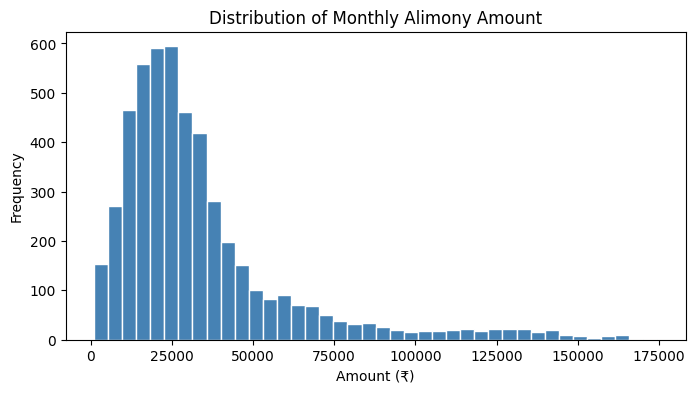

Mean   : ₹33,800
Median : ₹25,996
Mode   : ₹1,000
Std    : ₹27,859


In [22]:
plt.figure(figsize=(8,4))
plt.hist(df['monthly_alimony_amount'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Monthly Alimony Amount')
plt.xlabel('Amount (₹)')
plt.ylabel('Frequency')
plt.show()

print(f"Mean   : ₹{df['monthly_alimony_amount'].mean():,.0f}")
print(f"Median : ₹{df['monthly_alimony_amount'].median():,.0f}")
print(f"Mode   : ₹{df['monthly_alimony_amount'].mode()[0]:,.0f}")
print(f"Std    : ₹{df['monthly_alimony_amount'].std():,.0f}")

### 3.2 Correlation Heatmap

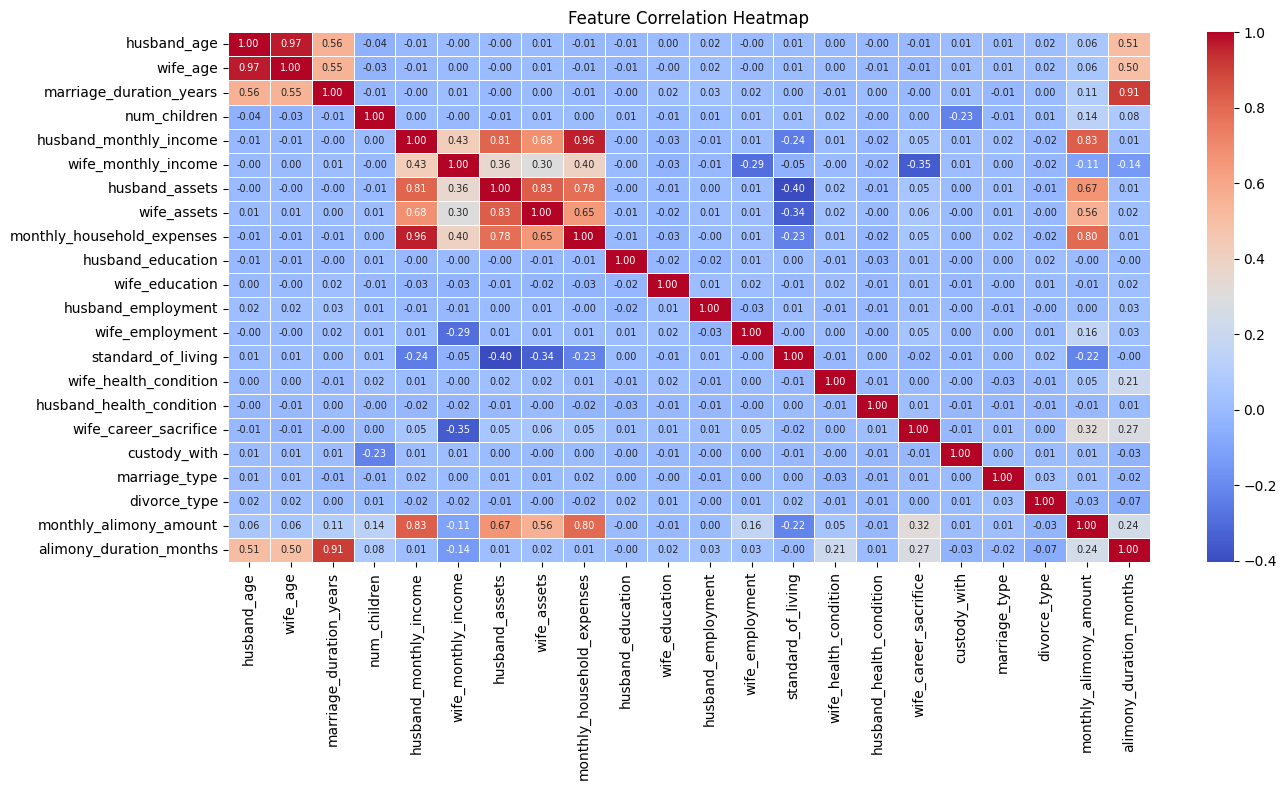

In [23]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## 4. Training

Split data 75/25, apply StandardScaler, and train a Linear Regression model.

In [24]:
x = df.drop(['monthly_alimony_amount', 'alimony_duration_months'], axis=1)
y1 = df['monthly_alimony_amount']
y2 = df['alimony_duration_months']

x_train, x_test, y1_train, y1_test = train_test_split(x, y1, test_size=0.25, random_state=42)
_,       _,      y2_train, y2_test = train_test_split(x, y2, test_size=0.25, random_state=42)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

# Model 1 — Monthly Alimony Amount
model1 = LinearRegression()
model1.fit(x_train, y1_train)
y1_pred = model1.predict(x_test)

# Model 2 — Alimony Duration
model2 = LinearRegression()
model2.fit(x_train, y2_train)
y2_pred = model2.predict(x_test)


---
## 5. Evaluation & Visualization

In [25]:
print('--- Monthly Alimony Amount ---')
print(f" MAE      : {mean_absolute_error(y1_test, y1_pred)}")
print(f" MSE      : {mean_squared_error(y1_test, y1_pred)}")
print(f" r2_score : {r2_score(y1_test, y1_pred)}")
print()
print('--- Alimony Duration (Months) ---')
print(f" MAE      : {mean_absolute_error(y2_test, y2_pred)}")
print(f" MSE      : {mean_squared_error(y2_test, y2_pred)}")
print(f" r2_score : {r2_score(y2_test, y2_pred)}")


--- Monthly Alimony Amount ---
 MAE      : 3314.4877718586504
 MSE      : 20828481.626411736
 r2_score : 0.9751375540171684

--- Alimony Duration (Months) ---
 MAE      : 11.893867132496261
 MSE      : 227.1542891302859
 r2_score : 0.9657796505337536


### Visualization of Linear Model


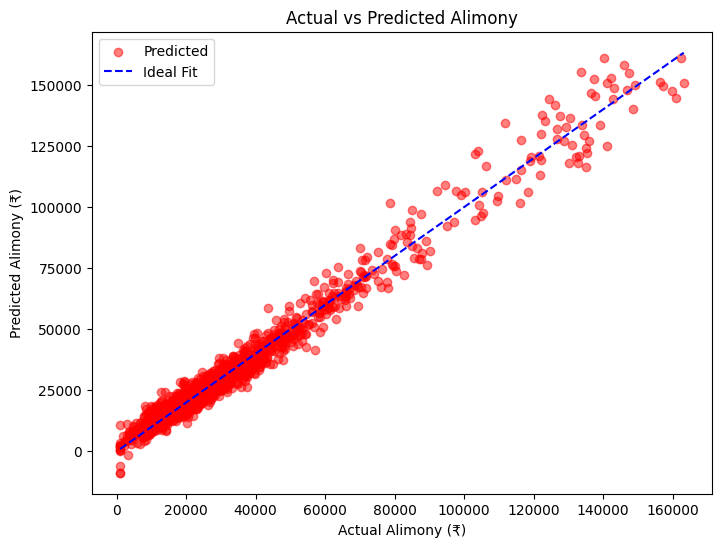

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y1_test, y1_pred, color="red", label="Predicted", alpha=0.5)
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'b--', label='Ideal Fit')
plt.xlabel("Actual Alimony (₹)")
plt.ylabel("Predicted Alimony (₹)")
plt.title("Actual vs Predicted Alimony")
plt.legend()
plt.show()


---
## 6. Model Comparison

Compare Linear Regression against Ridge, Random Forest, Gradient Boosting, and XGBoost.

In [27]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=100, random_state=42),
}

for name, m in models.items():
    m.fit(x_train, y1_train)
    pred = m.predict(x_test)
    print(f'{name}')
    print(f'  MAE: {mean_absolute_error(y1_test, pred):,.2f}  |  MSE: {mean_squared_error(y1_test, pred):,.2f}  |  R²: {r2_score(y1_test, pred):.4f}')
    print('-' * 60)

# save rf for feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y1_train)


Linear Regression
  MAE: 3,314.49  |  MSE: 20,828,481.63  |  R²: 0.9751
------------------------------------------------------------
Ridge
  MAE: 3,315.93  |  MSE: 20,839,900.24  |  R²: 0.9751
------------------------------------------------------------
Random Forest
  MAE: 3,882.55  |  MSE: 29,630,422.28  |  R²: 0.9646
------------------------------------------------------------
Gradient Boosting
  MAE: 3,569.38  |  MSE: 25,355,042.63  |  R²: 0.9697
------------------------------------------------------------
XGBoost
  MAE: 3,722.68  |  MSE: 29,045,552.00  |  R²: 0.9653
------------------------------------------------------------


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

---
## 7. Prediction on New Data

Provide new unseen cases and predict the monthly alimony amount using the trained model.

In [ ]:
new_data = pd.DataFrame({
    "husband_age":                  [45, 38, 52, 34, 60],
    "wife_age":                     [40, 35, 48, 30, 55],
    "marriage_duration_years":      [15,  8, 22,  5, 30],
    "num_children":                 [2, 1, 3, 0, 4],
    "husband_monthly_income":       [80000, 45000, 120000, 30000, 95000],
    "wife_monthly_income":          [20000,     0,  35000,     0, 10000],
    "husband_assets":               [500000, 200000, 1500000, 100000, 800000],
    "wife_assets":                  [100000,  50000,  300000,  20000, 150000],
    "monthly_household_expenses":   [30000, 15000, 50000, 8000, 40000],
    "husband_education":            ["Graduate", "12th Pass", "Postgraduate", "12th Pass", "Graduate"],
    "wife_education":               ["Graduate", "12th Pass", "Postgraduate", "12th Pass", "Graduate"],
    "husband_employment":           ["Employed", "Self-Employed", "Employed", "Unemployed", "Business"],
    "wife_employment":              ["Employed", "Unemployed", "Employed", "Homemaker", "Employed"],
    "standard_of_living":           ["High", "Low", "Upper-Middle", "Low", "Middle"],
    "wife_health_condition":        ["Good", "Moderate", "Good", "Poor", "Moderate"],
    "husband_health_condition":     ["Good", "Good", "Moderate", "Good", "Poor"],
    "wife_career_sacrifice":        ["Yes", "Yes", "No", "Yes", "No"],
    "custody_with":                 ["Wife", "Shared", "Shared", "Husband", "Wife"],
    "marriage_type":                ["Arranged", "Love", "Arranged", "Love", "Court Marriage"],
    "divorce_type":                 ["Mutual Consent", "Contested", "Mutual Consent", "Contested", "Mutual Consent"],
})

cat_cols = [
    "husband_education", "wife_education", "husband_employment", "wife_employment",
    "standard_of_living", "wife_health_condition", "husband_health_condition",
    "wife_career_sacrifice", "custody_with", "marriage_type", "divorce_type"
]

df_orig = pd.read_csv('../data/alimony_dataset.csv').drop('case_id', axis=1)
enc = LabelEncoder()
for col in cat_cols:
    enc.fit(df_orig[col])
    new_data[col] = enc.transform(new_data[col])

new_scaled    = sc.transform(new_data)
pred_amount   = model1.predict(new_scaled)
pred_duration = model2.predict(new_scaled)

print('Results:')
print('-' * 45)
for i in range(len(pred_amount)):
    print(f"Case {i+1}: ₹{pred_amount[i]:,.0f}/month  for  {int(pred_duration[i])} months")


Results:
---------------------------------------------
Case 1: ₹32,968/month  for  181 months
Case 2: ₹25,636/month  for  156 months
Case 3: ₹39,957/month  for  205 months
Case 4: ₹17,149/month  for  154 months
Case 5: ₹50,932/month  for  295 months


---
## 8. Feature Importance

Using Random Forest to identify which features influence alimony the most.

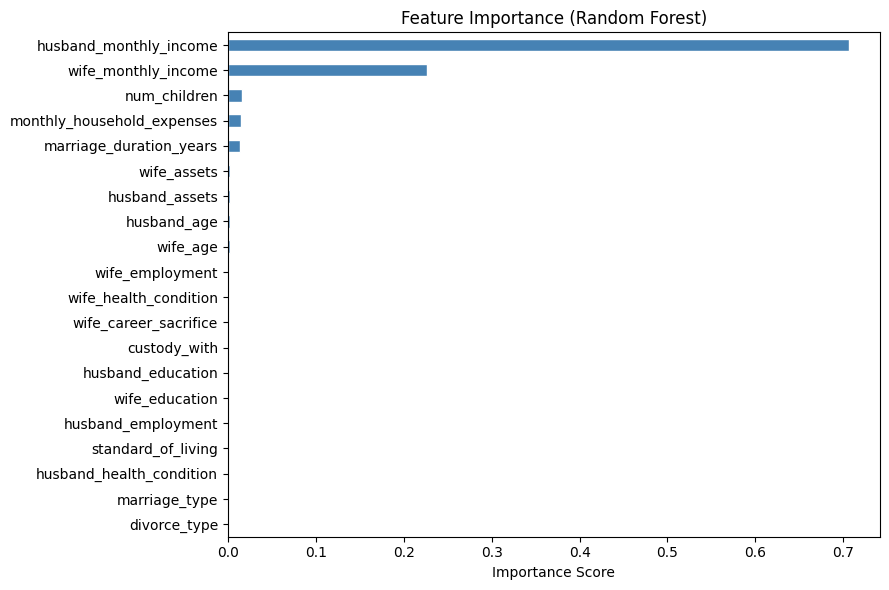

In [29]:
feature_names = df.drop(['monthly_alimony_amount', 'alimony_duration_months'], axis=1).columns

feat_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(9, 6), color='steelblue', edgecolor='white')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 9. Save Model

Save the best model using `joblib` for reuse without retraining.

In [30]:
import joblib

joblib.dump(model1, 'alimony_amount_model.pkl')
joblib.dump(model2, 'alimony_duration_model.pkl')
joblib.dump(sc,     'alimony_scaler.pkl')

print('Saved ✅')


Saved ✅


---
## 10. Conclusion

- The dataset had **5000 records** with 22 features after dropping `case_id`.
- `custody_with` had **869 missing values** which were filled using the mode.

- **Linear Regression** was used as the primary model, compared against Ridge, Random Forest, Gradient Boosting, and XGBoost.
- Key features influencing alimony include **husband's income, assets, marriage duration, and household expenses**.
- The model was tested on new unseen data and produced realistic predictions.
